In [2]:
import marineHeatWaves as mhw
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from datetime import date

In [3]:
ssts=np.load(r'C:\Users\Han\OneDrive\heat_budget\MHW_HB\2023_5_24汇报\25_05_2023_oisstv2r01_NEP.npy')

In [4]:
lon=np.arange(150,250,0.25)
lat=np.arange(20,60,0.25)
latind=(lat>=35)&(lat<=50)
lonind=(lon>=165)&(lon<=230)
sst=np.nanmean(ssts[latind,:,:][:,lonind,:],axis=(0,1))

t = np.arange(date(1981,9,1).toordinal(),date(2022,12,31).toordinal()+1)
time_mhw=pd.date_range('1981-09-01','2022-12-31',freq='1D')

In [5]:
mhws, clim = mhw.detect(t, sst,climatologyPeriod=[1982,2021])

In [6]:
mhws.keys()

dict_keys(['time_start', 'time_end', 'time_peak', 'date_start', 'date_end', 'date_peak', 'index_start', 'index_end', 'index_peak', 'duration', 'duration_moderate', 'duration_strong', 'duration_severe', 'duration_extreme', 'intensity_max', 'intensity_mean', 'intensity_var', 'intensity_cumulative', 'intensity_max_relThresh', 'intensity_mean_relThresh', 'intensity_var_relThresh', 'intensity_cumulative_relThresh', 'intensity_max_abs', 'intensity_mean_abs', 'intensity_var_abs', 'intensity_cumulative_abs', 'category', 'rate_onset', 'rate_decline', 'n_events'])

In [7]:
pd.to_datetime(mhws['date_peak'])

DatetimeIndex(['1990-12-27', '1991-04-15', '2000-09-08', '2002-05-10',
               '2005-01-15', '2009-02-02', '2011-08-18', '2011-12-12',
               '2012-09-04', '2013-05-05', '2013-07-17', '2013-08-06',
               '2013-08-30', '2014-01-08', '2014-04-16', '2014-06-28',
               '2014-08-08', '2014-08-29', '2014-09-18', '2015-02-17',
               '2015-03-14', '2015-04-02', '2015-06-08', '2015-08-27',
               '2015-10-07', '2016-08-14', '2016-09-08', '2018-10-13',
               '2018-11-21', '2019-07-31', '2019-08-27', '2019-10-14',
               '2019-11-09', '2020-01-12', '2020-02-14', '2020-03-01',
               '2020-04-19', '2020-09-21', '2020-11-13', '2020-12-20',
               '2021-02-27', '2021-06-10', '2021-09-16', '2021-10-14',
               '2022-02-16', '2022-08-27'],
              dtype='datetime64[ns]', freq=None)

In [8]:
def yermon(date):
    year = np.array(date.year,dtype=float)
    month = np.array(date.month,dtype=float)
    month[month<6]=0.
    month[month>=6]=0.5
    return(month+year)
def yearis(dat):
    elyear=[1951.5, 1952.0,1953.5, 1954.0,1957.5, 1958.0,1958.5, 1959.0,1963.5, 
            1964.0,1965.5, 1966.0,1968.5, 1969.0,1969.5, 1970.0,1972.5, 1973.0,
            1976.5, 1977.0,1977.5, 1978.0,1979.5, 1980.0,1982.5, 1983.0,1986.5, 
            1987.0,1987.5, 1988.0,1991.5, 1992.0,1994.5, 1995.0,1997.5,1998.0,
            2002.5,2003.0,2004.5,2005.0,2006.5,2007.0,2009.5,2010.0,2014.5,2015.0,
            2015.5,2016.0,2018.5,2019.0]
    layear=[1954.5, 1955.0,1955.5, 1956.0,1964.5, 1965.0,1970.5, 1971.0,1971.5, 
            1972.0,1973.5, 1974.0,1974.5, 1975.0,1975.5, 1976.0,1983.5, 1984.0,
            1984.5, 1985.0,1988.5, 1989.0,1995.5, 1996.0,1998.5, 1999.0,1999.5, 
            2000.0,2000.5, 2001.0,2005.5, 2006.0,2007.5, 2008.0,2008.5, 2009.0,
            2010.5, 2011.0,2011.5, 2012.0,2016.5, 2017.0,2017.5, 2018.0,2020.5, 
            2021.0,2021.5, 2022.0,2022.5]
    date=yermon(dat)
    if date in elyear:
        return 'el'
    elif date in layear:
        return 'la'
    else:
        return 'an'

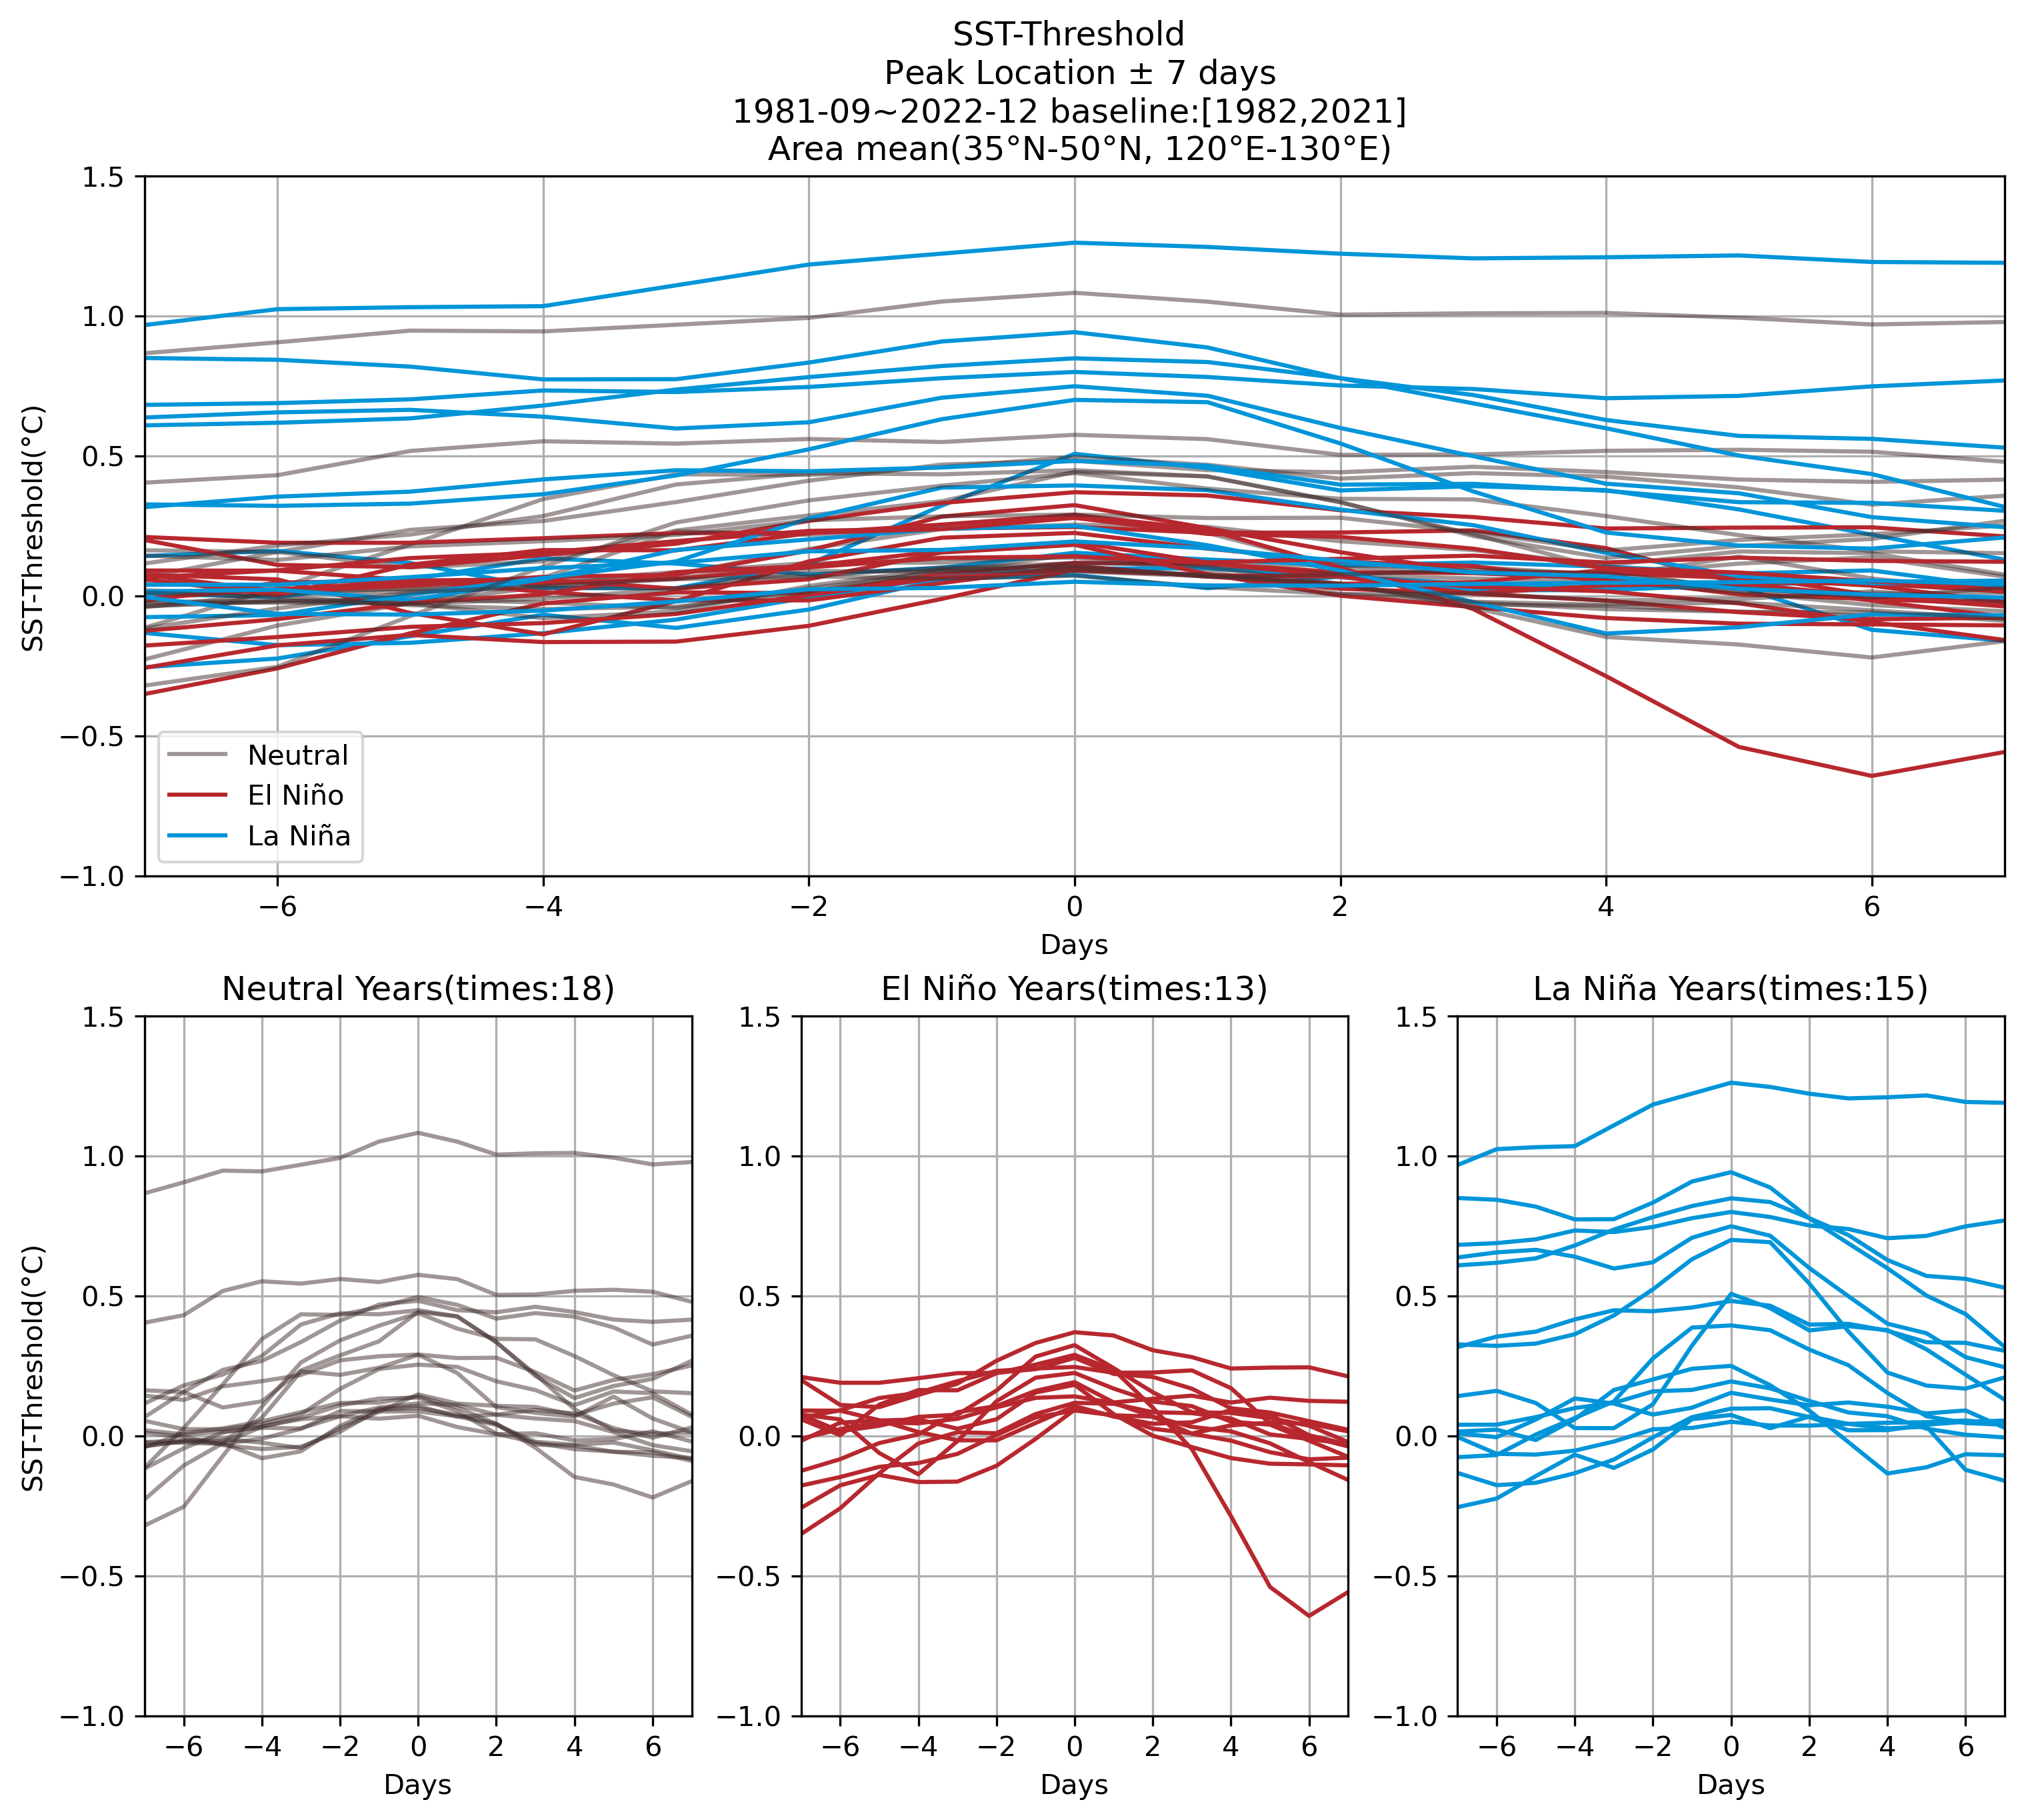

In [9]:
pl_time=pd.to_datetime(mhws['date_peak'])
ssta=sst-np.array(clim['thresh'])
plt.figure(figsize=(12,10),dpi=300)
plt.subplot(2,3,(1,3))
plt.plot(0,0,'#432f2f',alpha=0.5,label='Neutral')
plt.plot(0,0,'#b7282e',alpha=1,label='El Niño')
plt.plot(0,0,'#0095d9',alpha=1,label='La Niña')
plt.legend()
for i in pl_time:
    if yearis(i)=='an':
        plt.plot(
            np.arange(-7,7.1,1),
            ssta[(time_mhw>=(i-pd.Timedelta('7 days')))&(time_mhw<=(i+pd.Timedelta('7 days')))],
            '#432f2f',
            alpha=0.5
        )
    elif yearis(i)=='el':
        plt.plot(
            np.arange(-7,7.1,1),
            ssta[(time_mhw>=(i-pd.Timedelta('7 days')))&(time_mhw<=(i+pd.Timedelta('7 days')))],
            '#b7282e',
            alpha=1
        )
    elif yearis(i)=='la':
        plt.plot(
            np.arange(-7,7.1,1),
            ssta[(time_mhw>=(i-pd.Timedelta('7 days')))&(time_mhw<=(i+pd.Timedelta('7 days')))],
            '#0095d9',
            alpha=1
        )
plt.grid()
plt.title('SST-Threshold \n Peak Location $\pm$ 7 days\n1981-09~2022-12 baseline:[1982,2021] \n Area mean(35°N-50°N, 120°E-130°E)')
plt.xlabel('Days')
plt.ylabel('SST-Threshold(°C)')
plt.xlim(-7,7);plt.ylim(-1,1.5);plt.xticks(np.arange(-6,8,2))

plt.subplot(2,3,4)
n=0
for i in pl_time:
    if yearis(i)=='an':
        plt.plot(
            np.arange(-7,7.1,1),
            ssta[(time_mhw>=(i-pd.Timedelta('7 days')))&(time_mhw<=(i+pd.Timedelta('7 days')))],
            '#432f2f',
            alpha=0.5
        )
        n+=1
plt.grid()
plt.xlabel('Days')
plt.ylabel('SST-Threshold(°C)')
plt.title(f'Neutral Years(times:{n})')
plt.xlim(-7,7);plt.ylim(-1,1.5);plt.xticks(np.arange(-6,8,2))

plt.subplot(2,3,5)
n=0
for i in pl_time:
    if yearis(i)=='el':
        plt.plot(
            np.arange(-7,7.1,1),
            ssta[(time_mhw>=(i-pd.Timedelta('7 days')))&(time_mhw<=(i+pd.Timedelta('7 days')))],
            '#b7282e',
            alpha=1
        )
        n+=1
plt.grid()
plt.xlabel('Days')
plt.title(f'El Niño Years(times:{n})')
plt.xlim(-7,7);plt.ylim(-1,1.5);plt.xticks(np.arange(-6,8,2))

plt.subplot(2,3,6)
n=0
for i in pl_time:
    if yearis(i)=='la':
        plt.plot(
            np.arange(-7,7.1,1),
            ssta[(time_mhw>=(i-pd.Timedelta('7 days')))&(time_mhw<=(i+pd.Timedelta('7 days')))],
            '#0095d9',
            alpha=1
        )
        n+=1
plt.grid()
plt.xlabel('Days')
plt.title(f'La Niña Years(times:{n})')
plt.xlim(-7,7);plt.ylim(-1,1.5);plt.xticks(np.arange(-6,8,2))
plt.show()

In [10]:
data=np.load("20230525HeatBudget&HeatWave.npz")
mltt=np.array(data['mltt'])
Q=np.array(data['Q'])
hadv=np.array(data['hadv'])
mltt=mltt[:,:-1,:-1]
Q=Q[1:,:-1,:-1]
hadv=hadv[1:,:,:]

mltt=np.nanmean(mltt[:,latind,:][:,:,lonind],axis=(1,2))
Q=np.nanmean(Q[:,latind,:][:,:,lonind],axis=(1,2))
hadv=np.nanmean(hadv[:,latind,:][:,:,lonind],axis=(1,2))


In [11]:
times=pd.date_range('1993-01-01','2022-12-31',freq='1D')
times=times[1:]

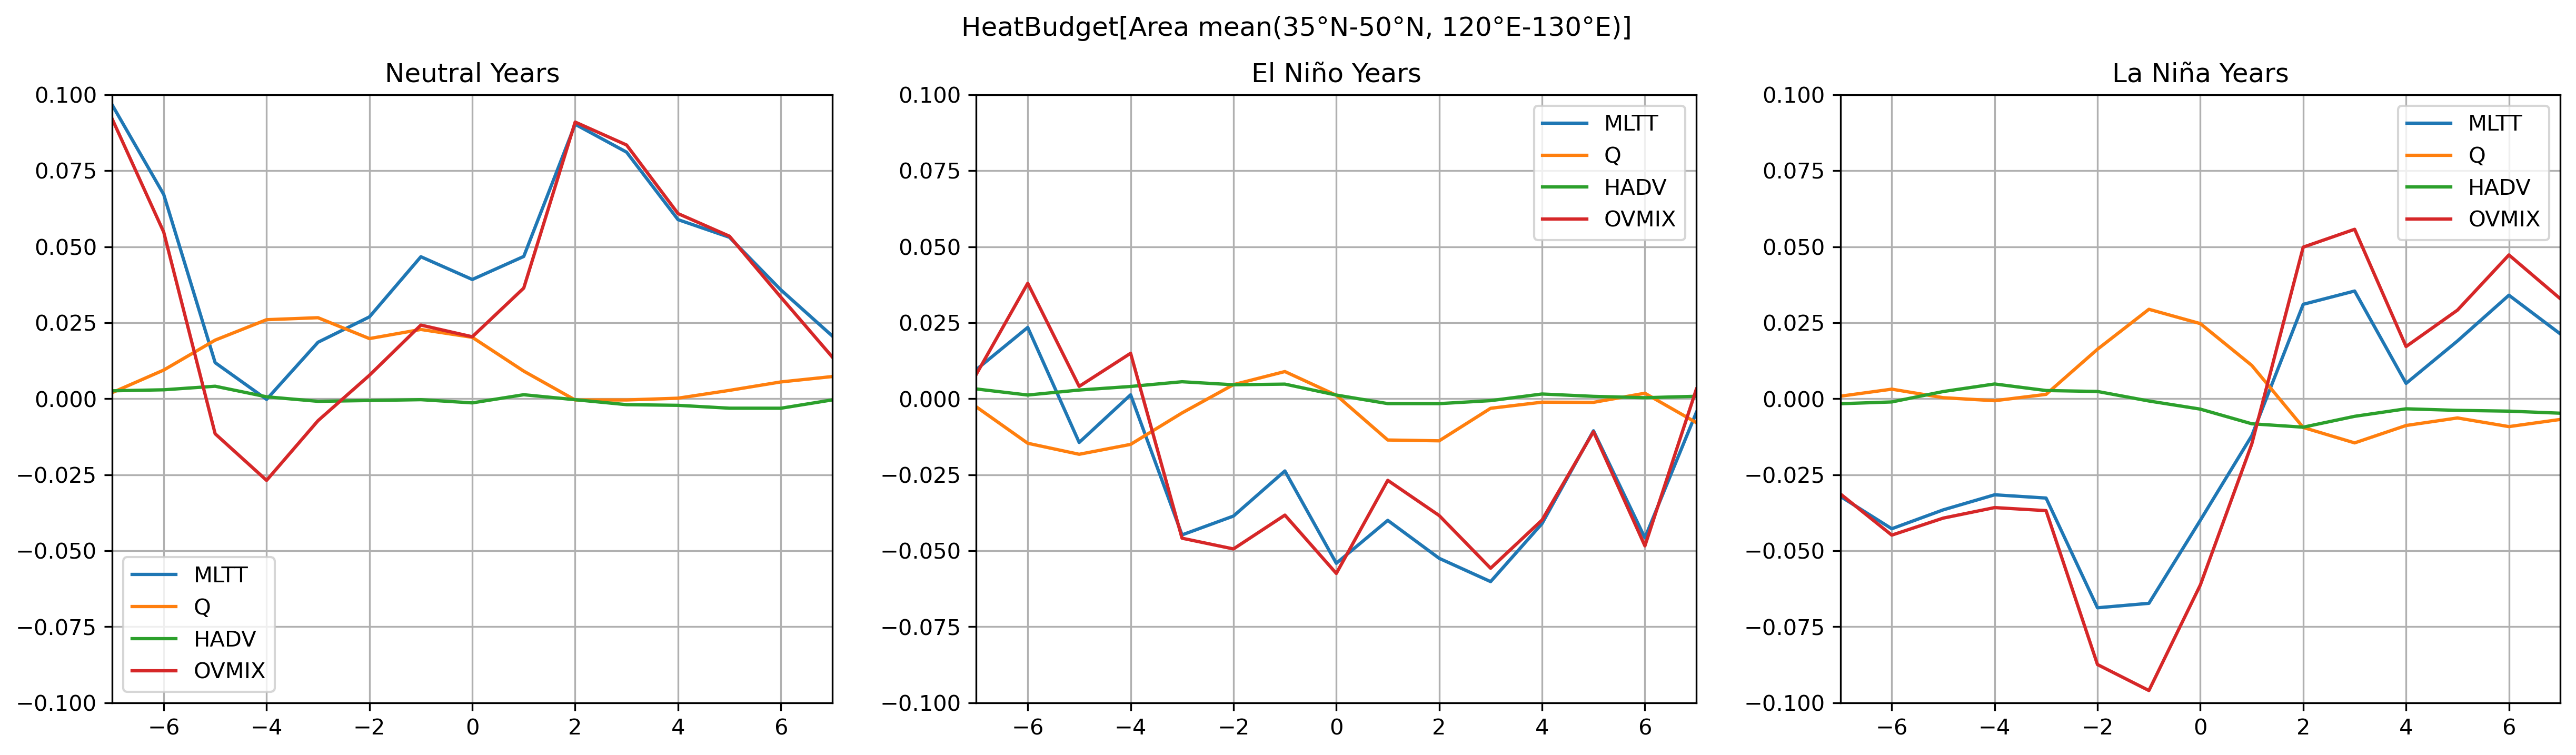

In [12]:
plt.figure(figsize=(20,5),dpi=300)
plt.suptitle('HeatBudget[Area mean(35°N-50°N, 120°E-130°E)]')
plt.subplot(1,3,1)
an_m=[];an_Q=[];an_h=[]
for i in pl_time:
    
    if (i>=times[0])&(yearis(i)=='an'):
        an_m.append(mltt[(times>=(i-pd.Timedelta('7 days')))&(times<=(i+pd.Timedelta('7 days')))])
        an_Q.append(Q[(times>=(i-pd.Timedelta('7 days')))&(times<=(i+pd.Timedelta('7 days')))])
        an_h.append(hadv[(times>=(i-pd.Timedelta('7 days')))&(times<=(i+pd.Timedelta('7 days')))])
an_m=np.array(an_m)
an_Q=np.array(an_Q)
an_h=np.array(an_h)
#an_m[-2,:]=np.nan
plt.plot(np.arange(-7,7.1,1),np.nanmean(np.array(an_m),axis=0),label='MLTT')
plt.plot(np.arange(-7,7.1,1),np.nanmean(np.array(an_Q),axis=0),label='Q')
plt.plot(np.arange(-7,7.1,1),np.nanmean(np.array(an_h),axis=0),label='HADV')
plt.plot(np.arange(-7,7.1,1),np.nanmean(np.array(an_m-an_Q-an_h),axis=0),label='OVMIX')
plt.legend();plt.grid();plt.xlim(-7,7);plt.ylim(-0.1,0.1);plt.xticks(np.arange(-6,8,2))
plt.title(f'Neutral Years')

plt.subplot(1,3,2)
el_m=[];el_Q=[];el_h=[]
for i in pl_time:
    if yearis(i)=='el':
        el_m.append(mltt[(times>=(i-pd.Timedelta('7 days')))&(times<=(i+pd.Timedelta('7 days')))])
        el_Q.append(Q[(times>=(i-pd.Timedelta('7 days')))&(times<=(i+pd.Timedelta('7 days')))])
        el_h.append(hadv[(times>=(i-pd.Timedelta('7 days')))&(times<=(i+pd.Timedelta('7 days')))])
el_m=np.array(el_m)
el_Q=np.array(el_Q)
el_h=np.array(el_h)
el_m[-2,:]=np.nan
plt.plot(np.arange(-7,7.1,1),np.nanmean(np.array(el_m),axis=0),label='MLTT')
plt.plot(np.arange(-7,7.1,1),np.nanmean(np.array(el_Q),axis=0),label='Q')
plt.plot(np.arange(-7,7.1,1),np.nanmean(np.array(el_h),axis=0),label='HADV')
plt.plot(np.arange(-7,7.1,1),np.nanmean(np.array(el_m-el_Q-el_h),axis=0),label='OVMIX')
plt.legend();plt.grid();plt.xlim(-7,7);plt.ylim(-0.1,0.1);plt.xticks(np.arange(-6,8,2))
plt.title(f'El Niño Years')

plt.subplot(1,3,3)
la_m=[];la_Q=[];la_h=[]
for i in pl_time:
    if yearis(i)=='la':
        la_m.append(mltt[(times>=(i-pd.Timedelta('7 days')))&(times<=(i+pd.Timedelta('7 days')))])
        la_Q.append(Q[(times>=(i-pd.Timedelta('7 days')))&(times<=(i+pd.Timedelta('7 days')))])
        la_h.append(hadv[(times>=(i-pd.Timedelta('7 days')))&(times<=(i+pd.Timedelta('7 days')))])
la_m=np.array(la_m)
la_Q=np.array(la_Q)
la_h=np.array(la_h)
#la_m[-2,:]=np.nan
plt.plot(np.arange(-7,7.1,1),np.nanmean(np.array(la_m),axis=0),label='MLTT')
plt.plot(np.arange(-7,7.1,1),np.nanmean(np.array(la_Q),axis=0),label='Q')
plt.plot(np.arange(-7,7.1,1),np.nanmean(np.array(la_h),axis=0),label='HADV')
plt.plot(np.arange(-7,7.1,1),np.nanmean(np.array(la_m-la_Q-la_h),axis=0),label='OVMIX')
plt.legend();plt.grid();plt.xlim(-7,7);plt.ylim(-0.1,0.1);plt.xticks(np.arange(-6,8,2))
plt.title(f'La Niña Years')
plt.show()

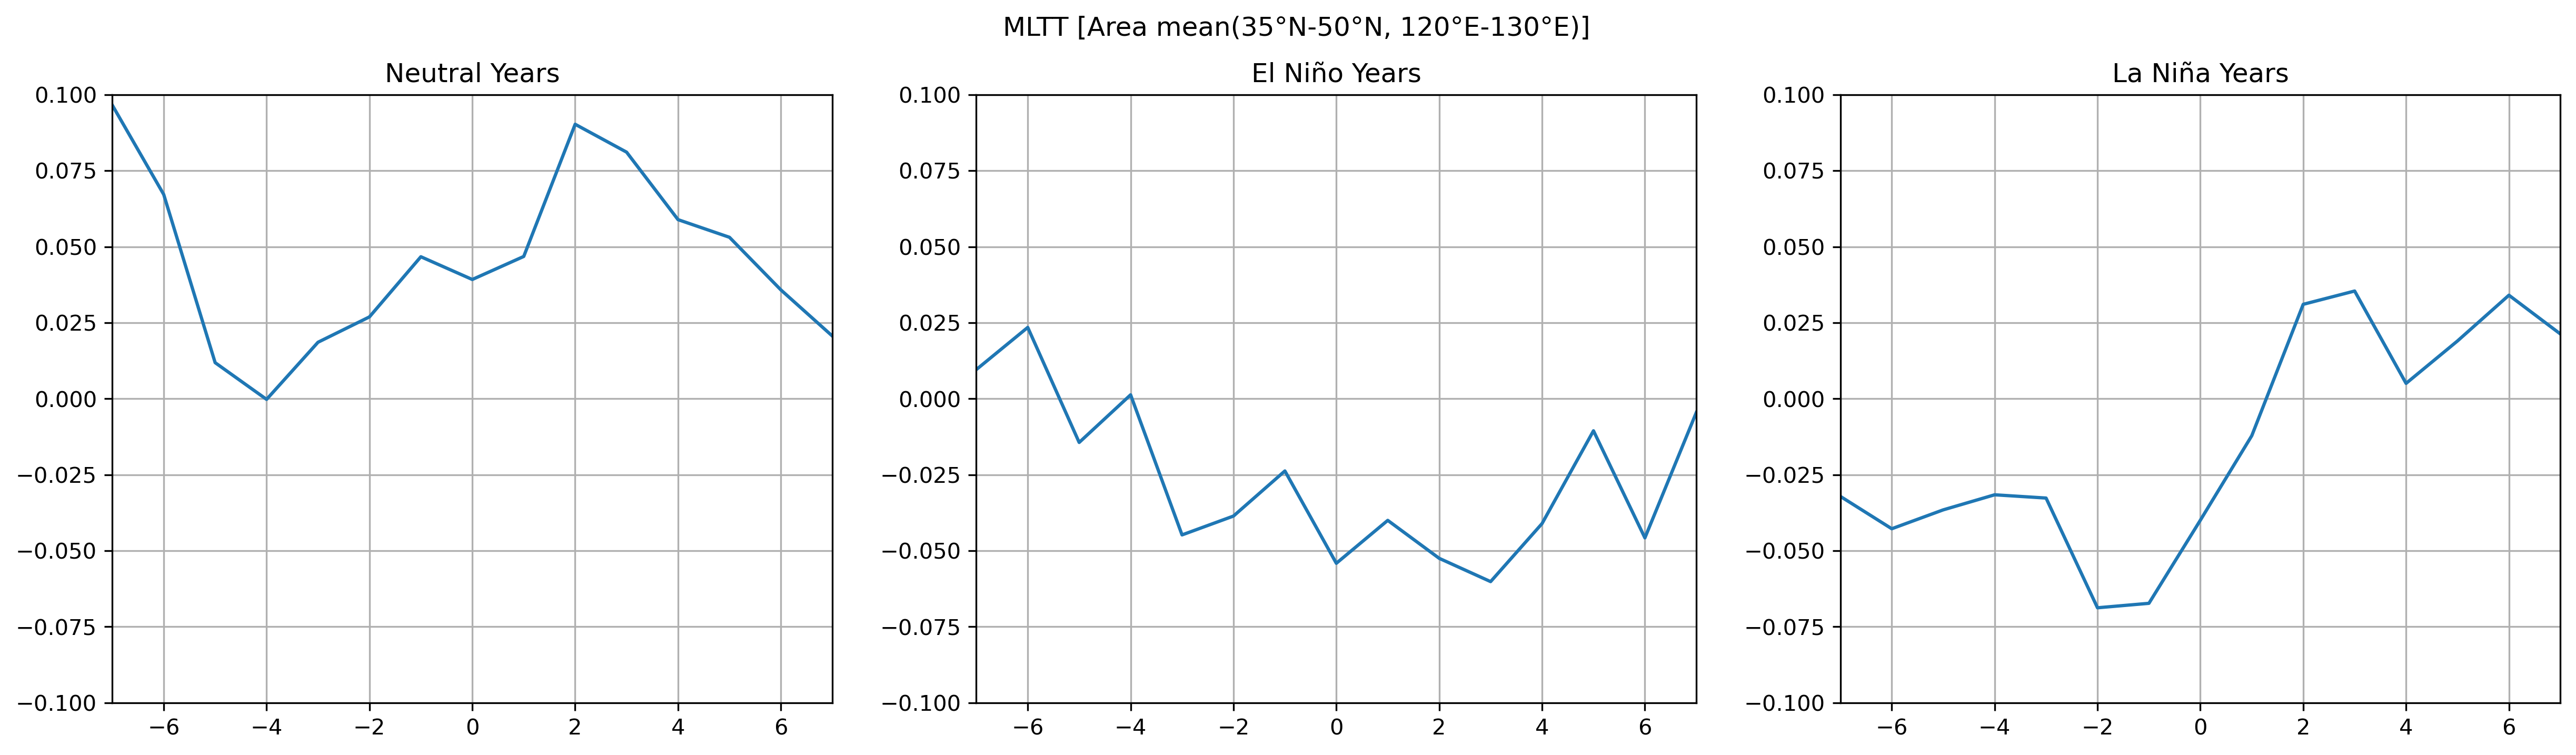

In [13]:
plt.figure(figsize=(20,5),dpi=300)
plt.suptitle('MLTT [Area mean(35°N-50°N, 120°E-130°E)]')
plt.subplot(1,3,1)
an_m=[];an_Q=[];an_h=[]
for i in pl_time:
    
    if (i>=times[0])&(yearis(i)=='an'):
        an_m.append(mltt[(times>=(i-pd.Timedelta('7 days')))&(times<=(i+pd.Timedelta('7 days')))])
        an_Q.append(Q[(times>=(i-pd.Timedelta('7 days')))&(times<=(i+pd.Timedelta('7 days')))])
        an_h.append(hadv[(times>=(i-pd.Timedelta('7 days')))&(times<=(i+pd.Timedelta('7 days')))])
an_m=np.array(an_m)
an_Q=np.array(an_Q)
an_h=np.array(an_h)
#an_m[-2,:]=np.nan
plt.plot(np.arange(-7,7.1,1),np.nanmean(np.array(an_m),axis=0),label='MLTT')
#plt.plot(np.arange(-7,7.1,1),np.nanmean(np.array(an_Q),axis=0),label='Q')
#plt.plot(np.arange(-7,7.1,1),np.nanmean(np.array(an_h),axis=0),label='HADV')
#plt.plot(np.arange(-7,7.1,1),np.nanmean(np.array(an_m-an_Q-an_h),axis=0),label='OVMIX')
plt.grid();plt.xlim(-7,7);plt.ylim(-0.1,0.1);plt.xticks(np.arange(-6,8,2))
plt.title(f'Neutral Years')

plt.subplot(1,3,2)
el_m=[];el_Q=[];el_h=[]
for i in pl_time:
    if yearis(i)=='el':
        el_m.append(mltt[(times>=(i-pd.Timedelta('7 days')))&(times<=(i+pd.Timedelta('7 days')))])
        el_Q.append(Q[(times>=(i-pd.Timedelta('7 days')))&(times<=(i+pd.Timedelta('7 days')))])
        el_h.append(hadv[(times>=(i-pd.Timedelta('7 days')))&(times<=(i+pd.Timedelta('7 days')))])
el_m=np.array(el_m)
el_Q=np.array(el_Q)
el_h=np.array(el_h)
el_m[-2,:]=np.nan
plt.plot(np.arange(-7,7.1,1),np.nanmean(np.array(el_m),axis=0),label='MLTT')
#plt.plot(np.arange(-7,7.1,1),np.nanmean(np.array(el_Q),axis=0),label='Q')
#plt.plot(np.arange(-7,7.1,1),np.nanmean(np.array(el_h),axis=0),label='HADV')
#plt.plot(np.arange(-7,7.1,1),np.nanmean(np.array(el_m-el_Q-el_h),axis=0),label='OVMIX')
plt.grid();plt.xlim(-7,7);plt.ylim(-0.1,0.1);plt.xticks(np.arange(-6,8,2))
plt.title(f'El Niño Years')

plt.subplot(1,3,3)
la_m=[];la_Q=[];la_h=[]
for i in pl_time:
    if yearis(i)=='la':
        la_m.append(mltt[(times>=(i-pd.Timedelta('7 days')))&(times<=(i+pd.Timedelta('7 days')))])
        la_Q.append(Q[(times>=(i-pd.Timedelta('7 days')))&(times<=(i+pd.Timedelta('7 days')))])
        la_h.append(hadv[(times>=(i-pd.Timedelta('7 days')))&(times<=(i+pd.Timedelta('7 days')))])
la_m=np.array(la_m)
la_Q=np.array(la_Q)
la_h=np.array(la_h)
#la_m[-2,:]=np.nan
plt.plot(np.arange(-7,7.1,1),np.nanmean(np.array(la_m),axis=0),label='MLTT')
#plt.plot(np.arange(-7,7.1,1),np.nanmean(np.array(la_Q),axis=0),label='Q')
#plt.plot(np.arange(-7,7.1,1),np.nanmean(np.array(la_h),axis=0),label='HADV')
#plt.plot(np.arange(-7,7.1,1),np.nanmean(np.array(la_m-la_Q-la_h),axis=0),label='OVMIX')
plt.grid();plt.xlim(-7,7);plt.ylim(-0.1,0.1);plt.xticks(np.arange(-6,8,2))
plt.title(f'La Niña Years')
plt.show()

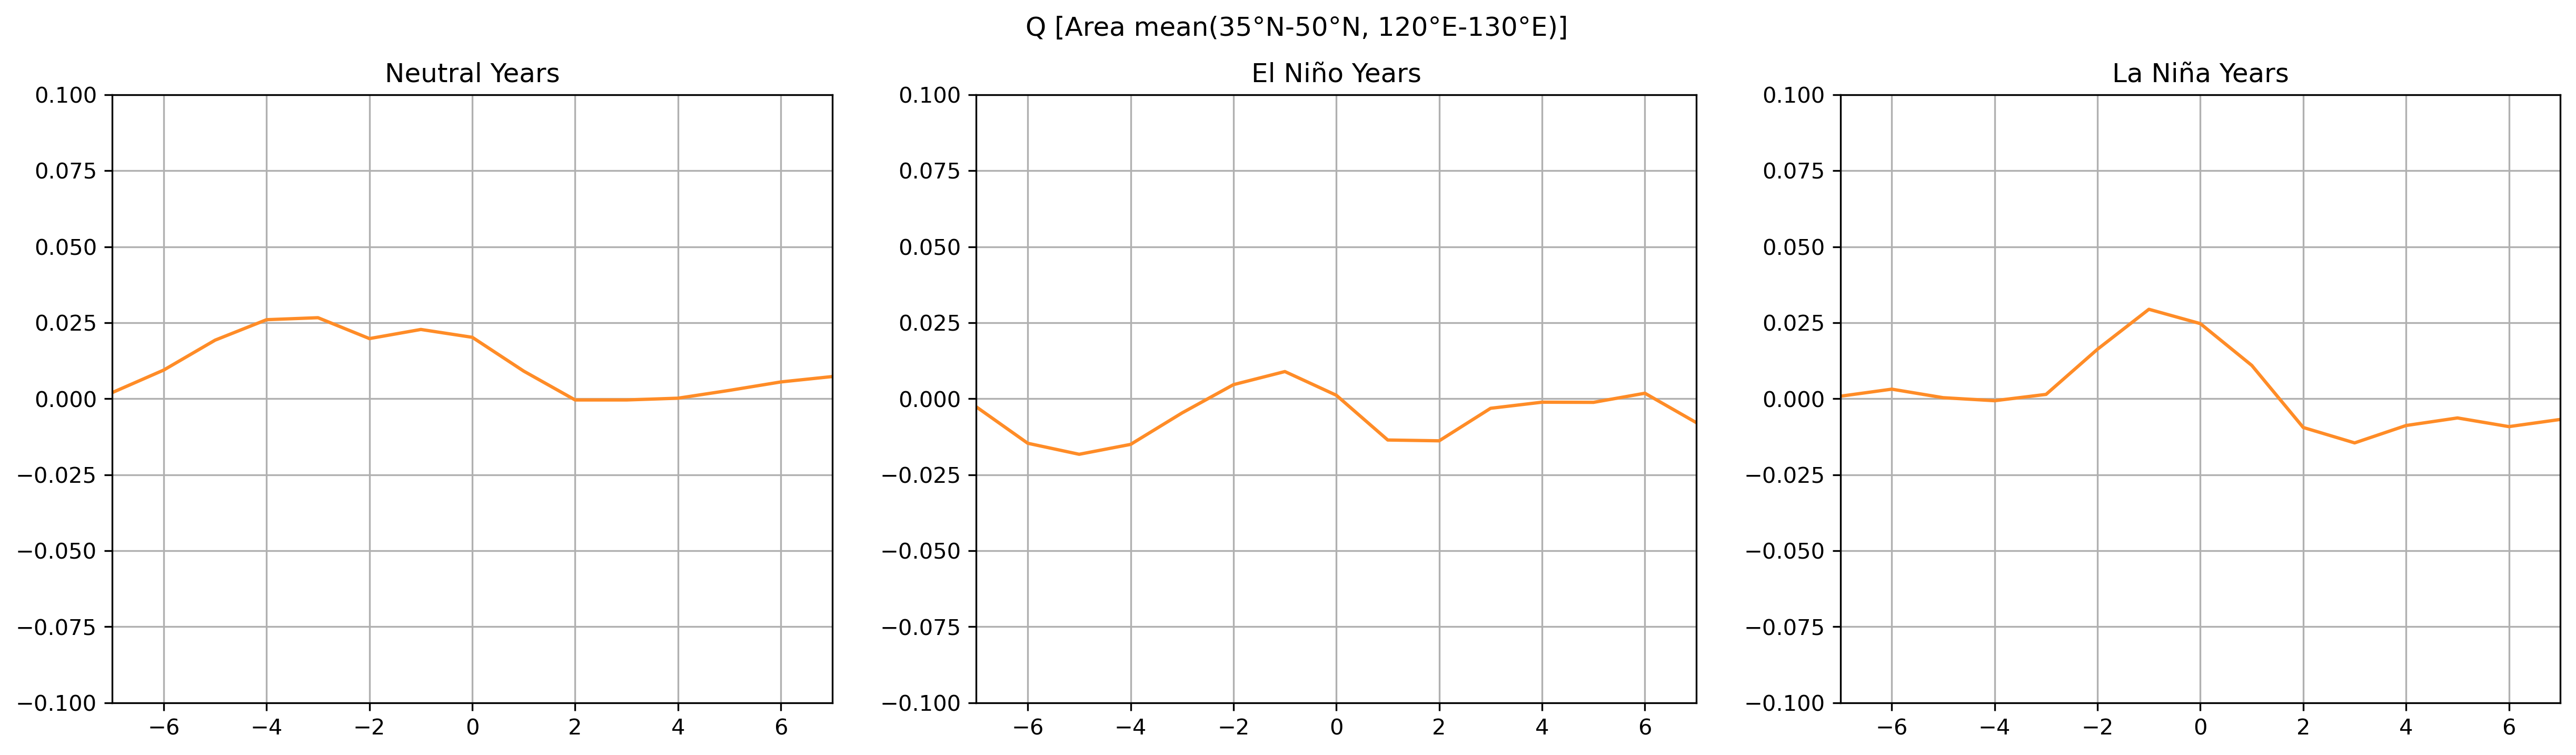

In [14]:
plt.figure(figsize=(20,5),dpi=300)
plt.suptitle('Q [Area mean(35°N-50°N, 120°E-130°E)]')
plt.subplot(1,3,1)
an_m=[];an_Q=[];an_h=[]
for i in pl_time:
    
    if (i>=times[0])&(yearis(i)=='an'):
        an_m.append(mltt[(times>=(i-pd.Timedelta('7 days')))&(times<=(i+pd.Timedelta('7 days')))])
        an_Q.append(Q[(times>=(i-pd.Timedelta('7 days')))&(times<=(i+pd.Timedelta('7 days')))])
        an_h.append(hadv[(times>=(i-pd.Timedelta('7 days')))&(times<=(i+pd.Timedelta('7 days')))])
an_m=np.array(an_m)
an_Q=np.array(an_Q)
an_h=np.array(an_h)
#an_m[-2,:]=np.nan
#plt.plot(np.arange(-7,7.1,1),np.nanmean(np.array(an_m),axis=0),label='MLTT')
plt.plot(np.arange(-7,7.1,1),np.nanmean(np.array(an_Q),axis=0),label='Q',color='#ff8c27')
#plt.plot(np.arange(-7,7.1,1),np.nanmean(np.array(an_h),axis=0),label='HADV')
#plt.plot(np.arange(-7,7.1,1),np.nanmean(np.array(an_m-an_Q-an_h),axis=0),label='OVMIX')
plt.grid();plt.xlim(-7,7);plt.ylim(-0.1,0.1);plt.xticks(np.arange(-6,8,2))
plt.title(f'Neutral Years')

plt.subplot(1,3,2)
el_m=[];el_Q=[];el_h=[]
for i in pl_time:
    if yearis(i)=='el':
        el_m.append(mltt[(times>=(i-pd.Timedelta('7 days')))&(times<=(i+pd.Timedelta('7 days')))])
        el_Q.append(Q[(times>=(i-pd.Timedelta('7 days')))&(times<=(i+pd.Timedelta('7 days')))])
        el_h.append(hadv[(times>=(i-pd.Timedelta('7 days')))&(times<=(i+pd.Timedelta('7 days')))])
el_m=np.array(el_m)
el_Q=np.array(el_Q)
el_h=np.array(el_h)
el_m[-2,:]=np.nan
#plt.plot(np.arange(-7,7.1,1),np.nanmean(np.array(el_m),axis=0),label='MLTT')
plt.plot(np.arange(-7,7.1,1),np.nanmean(np.array(el_Q),axis=0),label='Q',color='#ff8c27')
#plt.plot(np.arange(-7,7.1,1),np.nanmean(np.array(el_h),axis=0),label='HADV')
#plt.plot(np.arange(-7,7.1,1),np.nanmean(np.array(el_m-el_Q-el_h),axis=0),label='OVMIX')
plt.grid();plt.xlim(-7,7);plt.ylim(-0.1,0.1);plt.xticks(np.arange(-6,8,2))
plt.title(f'El Niño Years')

plt.subplot(1,3,3)
la_m=[];la_Q=[];la_h=[]
for i in pl_time:
    if yearis(i)=='la':
        la_m.append(mltt[(times>=(i-pd.Timedelta('7 days')))&(times<=(i+pd.Timedelta('7 days')))])
        la_Q.append(Q[(times>=(i-pd.Timedelta('7 days')))&(times<=(i+pd.Timedelta('7 days')))])
        la_h.append(hadv[(times>=(i-pd.Timedelta('7 days')))&(times<=(i+pd.Timedelta('7 days')))])
la_m=np.array(la_m)
la_Q=np.array(la_Q)
la_h=np.array(la_h)
#la_m[-2,:]=np.nan
#plt.plot(np.arange(-7,7.1,1),np.nanmean(np.array(la_m),axis=0),label='MLTT')
plt.plot(np.arange(-7,7.1,1),np.nanmean(np.array(la_Q),axis=0),label='Q',color='#ff8c27')
#plt.plot(np.arange(-7,7.1,1),np.nanmean(np.array(la_h),axis=0),label='HADV')
#plt.plot(np.arange(-7,7.1,1),np.nanmean(np.array(la_m-la_Q-la_h),axis=0),label='OVMIX')
plt.grid();plt.xlim(-7,7);plt.ylim(-0.1,0.1);plt.xticks(np.arange(-6,8,2))
plt.title(f'La Niña Years')
plt.show()

In [18]:
np.savez('dataForHC.npz',sst=sst,thresh=np.array(clim['thresh']),clim=np.array(clim['seas']),pl_time=pl_time,time_mhw=time_mhw,mltt=mltt,Q=Q,hadv=hadv,time_hb=times)

In [17]:
clim.keys()

dict_keys(['thresh', 'seas', 'missing'])